<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/salary_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd

In [93]:
data = pd.read_csv("/content/drive/MyDrive/CDPL SEM 3/dataset/SalaryData.csv")

In [94]:
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [95]:
#Checking columns of dataset
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  387 non-null    float64
 1   Gender               387 non-null    object 
 2   Education Level      387 non-null    object 
 3   Job Title            386 non-null    object 
 4   Years of Experience  385 non-null    float64
 5   Salary               384 non-null    float64
dtypes: float64(3), object(3)
memory usage: 18.4+ KB


In [97]:
# checking shape of the data
data.shape

(390, 6)

In [98]:
#checking null values
data.isnull().sum()

,0
Age,3
Gender,3
Education Level,3
Job Title,4
Years of Experience,5
Salary,6


In [99]:
 # value count of gender
 data['Gender'].value_counts()

,count
Gender,
Male,195
Female,180
FEMALE,3
MALE,2
female,2
Unknown,2
male,1
male,1
femle,1


In [100]:
 # value count of education level
 data['Education Level'].value_counts()

,count
Education Level,
Bachelor's,224
Master's,99
PhD,52
Bachelors,3
Masters,3
Phd,3
masters,2
bachelor,1


In [101]:
 # value count of Age
 data['Age'].value_counts()

,count
Age,
33.0,24
29.0,24
35.0,22
44.0,22
31.0,21
36.0,20
30.0,18
34.0,18
45.0,18


In [102]:
# checking unique values in Gender
data['Gender'].unique()

array(['Male', 'Female', nan, 'male', 'FEMALE', 'male ', 'femle',
       'female', 'MALE', 'Unknown'], dtype=object)

In [103]:
# checking unique values in Education Level
data['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', nan, 'Bachelors', 'Masters',
       'Phd', 'bachelor', 'masters'], dtype=object)

In [104]:
#Statistical description of the data
data.describe()

,Age,Years of Experience,Salary
count,387.000000,385.000000,3.840000e+02
mean,39.635659,10.050649,1.058993e+05
std,49.509188,6.896418,1.028712e+05
min,-5.000000,0.000000,-2.000000e+04
25%,31.000000,4.000000,5.500000e+04
50%,36.000000,9.000000,9.500000e+04
75%,44.000000,15.000000,1.400000e+05
max,1000.000000,50.000000,1.500000e+06


In [105]:
# Removing extreme values from Age
data = data[data['Age'] >= 18]
data = data[data['Age'] < 65]

In [106]:
# Droping the missing values
data = data.dropna()

In [107]:
# confirming that missing rows are dropped
data.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [108]:
data['Gender'].unique()

array(['Male', 'Female', 'male', 'FEMALE', 'female', 'MALE'], dtype=object)

In [109]:
# solving inconsistancy
data['Gender'] = data['Gender'].str.lower()

In [110]:
# stripping the space
data['Gender'] = data['Gender'].str.strip()

In [111]:
#Confirming the changes
data['Gender'].value_counts()

,count
Gender,
male,197
female,183


Solving inconsistancy in Education Level

In [112]:
data['Education Level'] = data['Education Level'].str.lower()
data['Education Level'] = data['Education Level'].str.strip()

In [113]:
data['Education Level'].unique()

array(["bachelor's", "master's", 'phd', 'bachelors', 'masters'],
      dtype=object)

In [114]:
# Going to replace incorrect names with correct name
edu_correct = {
    "bachelors" : "bachelor's",
    "masters" : "master's"
}

In [115]:
#Replaceing names
data['Education Level'] = data['Education Level'].replace(edu_correct)

In [116]:
#Checking if it worked or not
data['Education Level'].unique()

array(["bachelor's", "master's", 'phd'], dtype=object)

In [117]:
data['Education Level'].value_counts()

,count
Education Level,
bachelor's,225
master's,102
phd,53


## **DATA Visualization**

## Univariate DATA Analysis

In [118]:
#Importing visualization libs
import matplotlib.pyplot as plt
import seaborn as sns

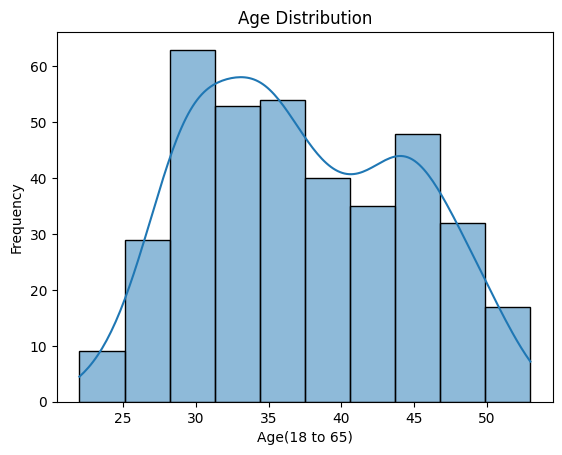

<Figure size 800x600 with 0 Axes>

In [119]:
# Histogram of Age
sns.histplot(data['Age'], kde = True)
plt.title('Age Distribution')
plt.xlabel('Age(18 to 65)')
plt.ylabel('Frequency')
plt.figure(figsize=(8,6))
plt.show()

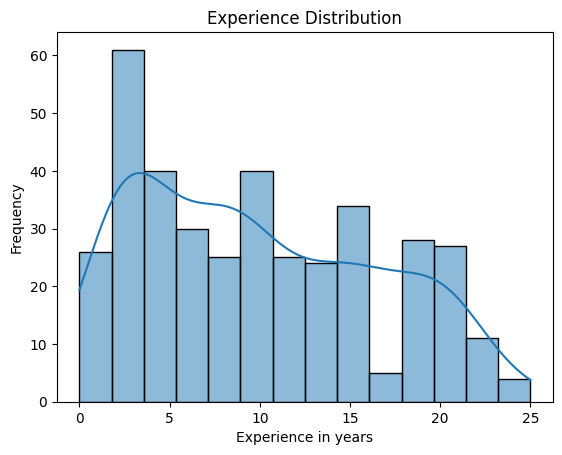

<Figure size 800x600 with 0 Axes>

In [120]:
# Histogram of Year of Experince
sns.histplot(data['Years of Experience'], bins = 14, kde = True)
plt.title('Experience Distribution')
plt.xlabel('Experience in years')
plt.ylabel('Frequency')
plt.figure(figsize=(8,6))
plt.show()

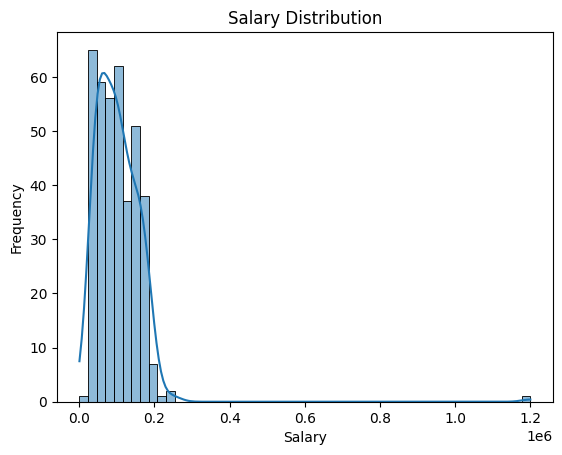

In [121]:
#Histogram of salary
sns.histplot(data['Salary'], kde = True)
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel("Frequency")
plt.show()

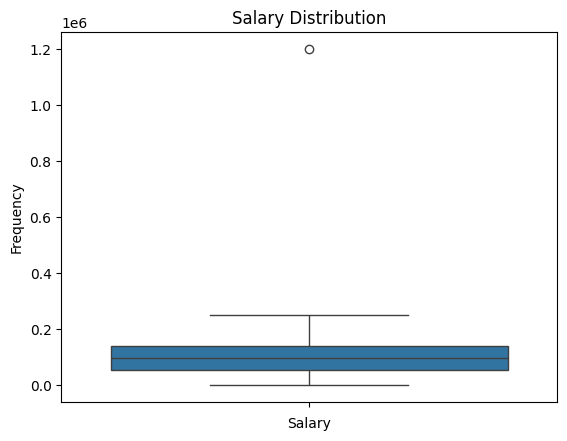

In [123]:
#Boxplot of Salary
sns.boxplot(data['Salary'])
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel("Frequency")
plt.show()

In [126]:
#Remoing outlier from the salary
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#for removing outlier
data = data[(data['Salary'] <= upper_bound)]

#for clipping
#data['Salary'] = data['Salary'].clip(upper_bound)

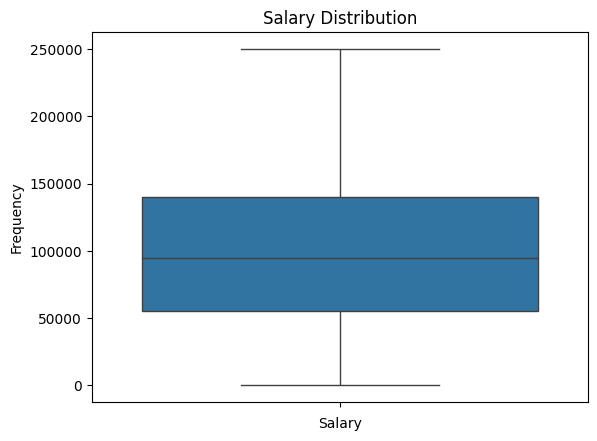

In [127]:
#Boxplot of salary after Quantiles
sns.boxplot(data['Salary'])
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel("Frequency")
plt.show()

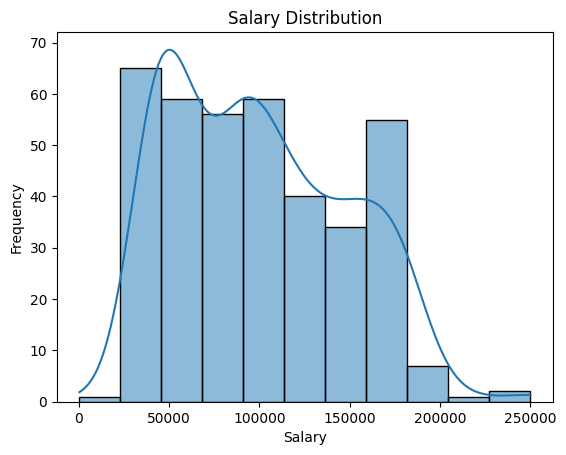

In [128]:
#Histogram of salary after removing outlier
sns.histplot(data['Salary'], kde = True)
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel("Frequency")
plt.show()

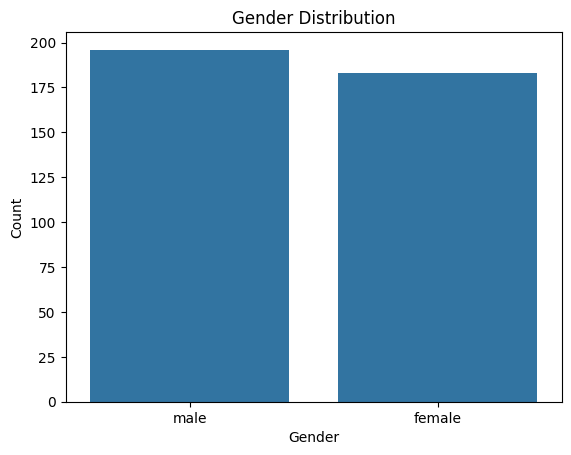

In [131]:
#Countplot of Gender
sns.countplot(data = data, x = 'Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

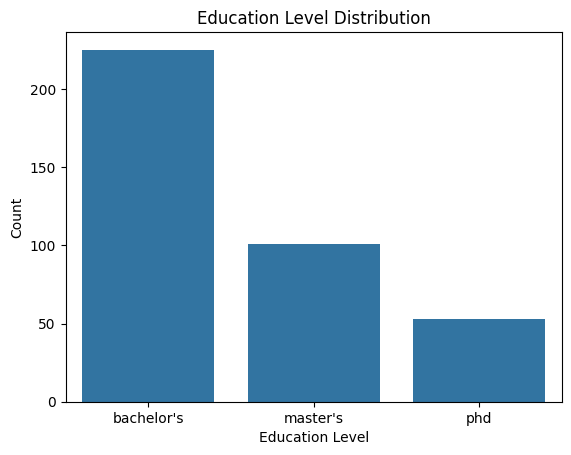

In [136]:
#Countplot of Education Level
sns.countplot(data = data, x = 'Education Level')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis